# 06 — SSP Poverty Predictions

Apply the best trained model for each poverty threshold to the full SSP forecast
panel (SSP1, SSP4, SSP5) and produce the prediction file consumed by the dashboard.

## Outputs

| File | Description |
|------|-------------|
| `data/final/poverty_predictions_ssp.csv` | Main dashboard feed: all countries × scenarios × years × thresholds |
| `outputs/top10_countries_by_scenario.csv` | Top-10 highest poverty countries per SSP × threshold × year |
| `outputs/prediction_summary_stats.csv` | Mean/median/std/p10/p90 by scenario × threshold × year |
| `outputs/prediction_trajectories_{threshold}.png` | Country-level trajectory charts |
| `outputs/prediction_global_heatmap.png` | Region-level poverty heatmap |

## Schema of `poverty_predictions_ssp.csv`

```
country_name        — IIASA country name
country_code        — ISO 3166-1 alpha-3
scenario            — SSP1 / SSP4 / SSP5
year                — 2025, 2030, …, 2100 (5-year steps)
poverty_threshold   — $3 / $4.20 / $8.30 / $10
predicted_poverty   — headcount ratio (%), clipped [0, 100]
approach            — A (year ≤ 2050) or B (year > 2050)
extrapolation_flag  — True if any input feature is source-extrapolated
```


## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from predict_ssp import (
    run_predictions,
    select_best_models,
    APPROACH_A_YEARS,
    APPROACH_B_YEARS,
    THRESHOLD_DISPLAY,
)
from config import DATA_FINAL_DIR, DATA_PROCESSED_DIR, OUTPUTS_DIR, SSP_SCENARIOS
from model_pipeline import ALL_THRESHOLDS, MODEL_NAMES
from utils import SCENARIO_COLORS

print("Approach A years:", APPROACH_A_YEARS)
print("Approach B years:", APPROACH_B_YEARS)

Approach A years: [2025, 2030, 2035, 2040, 2045, 2050]
Approach B years: [2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100]


## 1. Confirm model training is complete

In [2]:
from config import MODELS_DIR

model_files = list(MODELS_DIR.glob("*_approach_a.pkl"))
print(f"Model files found: {len(model_files)} (expected: {len(ALL_THRESHOLDS) * len(MODEL_NAMES)})")
for f in sorted(model_files):
    print(f"  {f.name}")

if len(model_files) == 0:
    print("\n⚠  No model files found. Run 03_model_training.ipynb first.")
else:
    print("\n✓ Model files present — ready to predict.")

Model files found: 28 (expected: 24)
  gam_10_approach_a.pkl
  gam_3_approach_a.pkl
  gam_4_20_approach_a.pkl
  gam_8_30_approach_a.pkl
  lightgbm_10_approach_a.pkl
  lightgbm_3_approach_a.pkl
  lightgbm_4_20_approach_a.pkl
  lightgbm_8_30_approach_a.pkl
  mlp_10_approach_a.pkl
  mlp_3_approach_a.pkl
  mlp_4_20_approach_a.pkl
  mlp_8_30_approach_a.pkl
  random_forest_10_approach_a.pkl
  random_forest_3_approach_a.pkl
  random_forest_4_20_approach_a.pkl
  random_forest_8_30_approach_a.pkl
  ridge_10_approach_a.pkl
  ridge_3_approach_a.pkl
  ridge_4_20_approach_a.pkl
  ridge_8_30_approach_a.pkl
  xgboost_cpu_10_approach_a.pkl
  xgboost_cpu_3_approach_a.pkl
  xgboost_cpu_4_20_approach_a.pkl
  xgboost_cpu_8_30_approach_a.pkl
  xgboost_gpu_10_approach_a.pkl
  xgboost_gpu_3_approach_a.pkl
  xgboost_gpu_4_20_approach_a.pkl
  xgboost_gpu_8_30_approach_a.pkl

✓ Model files present — ready to predict.


## 2. Best-model selection

In [3]:
best_models = select_best_models(OUTPUTS_DIR)
print("Best model per threshold (lowest test RMSE):")
for threshold, model in best_models.items():
    print(f"  {threshold:<8} → {model}")

# Show the comparison table for reference
csv_path = OUTPUTS_DIR / "model_comparison_by_threshold.csv"
if csv_path.exists():
    comp = pd.read_csv(csv_path)
    print("\nFull comparison (test RMSE):")
    print(
        comp[["model_name", "threshold", "rmse", "r2"]]
        .sort_values(["threshold", "rmse"])
        .to_string(index=False)
    )

Best model per threshold (lowest test RMSE):
  $3       → random_forest
  $4.20    → random_forest
  $8.30    → xgboost_cpu
  $10      → xgboost_cpu

Full comparison (test RMSE):
   model_name threshold         rmse        r2
  xgboost_cpu       $10 7.283158e+00  0.946454
  xgboost_gpu       $10 7.283158e+00  0.946454
          mlp       $10 8.455190e+00  0.927833
random_forest       $10 8.708139e+00  0.923451
          gam       $10 9.022984e+00  0.917815
        ridge       $10 1.102607e+01  0.877275
random_forest        $3 2.219288e+12 -0.059276
  xgboost_cpu        $3 2.219288e+12 -0.059276
  xgboost_gpu        $3 2.219288e+12 -0.059276
        ridge        $3 2.219288e+12 -0.059276
          gam        $3 2.219288e+12 -0.059276
          mlp        $3 2.219288e+12 -0.059276
random_forest     $4.20 2.219288e+12 -0.059276
  xgboost_cpu     $4.20 2.219288e+12 -0.059276
  xgboost_gpu     $4.20 2.219288e+12 -0.059276
        ridge     $4.20 2.219288e+12 -0.059276
          gam     $4.2

## 3. Inspect the forecast panel

In [4]:
panel = pd.read_csv(DATA_PROCESSED_DIR / "ssp_forecast_panel.csv")
print(f"Shape:     {panel.shape}")
print(f"Countries: {panel['country_name'].nunique()}")
print(f"Scenarios: {panel['scenario'].unique()}")
print(f"Years:     {panel['year'].min()} – {panel['year'].max()}")
print(f"Columns:   {panel.columns.tolist()}")

# Extrapolation flag summary
for col in ["employment_agriculture_extrap", "hdi_extrap", "coc_extrap"]:
    if col in panel.columns:
        n = panel[col].astype(bool).sum()
        yrs = sorted(panel[panel[col].astype(bool)]["year"].unique())
        print(f"  {col}: {n:,} rows  |  years: {yrs[:5]}…")

Shape:     (9600, 13)
Countries: 200
Scenarios: ['SSP1' 'SSP4' 'SSP5']
Years:     2025 – 2100
Columns:   ['country_name', 'country_code', 'scenario', 'year', 'gdp_per_capita', 'population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'employment_agriculture_extrap', 'hdi_extrap', 'coc_extrap']
  employment_agriculture_extrap: 6,000 rows  |  years: [np.int64(2055), np.int64(2060), np.int64(2065), np.int64(2070), np.int64(2075)]…
  hdi_extrap: 3,000 rows  |  years: [np.int64(2080), np.int64(2085), np.int64(2090), np.int64(2095), np.int64(2100)]…
  coc_extrap: 600 rows  |  years: [np.int64(2100)]…


## 4. Run predictions

In [5]:
# Generates all 4 thresholds × 3 scenarios × all years in one call.
predictions = run_predictions(
    forecast_panel_path = DATA_PROCESSED_DIR / "ssp_forecast_panel.csv",
    scaler_path         = DATA_FINAL_DIR     / "feature_scaler.pkl",
    feature_names_path  = DATA_FINAL_DIR     / "feature_names.json",
    models_dir          = MODELS_DIR,
    outputs_dir         = OUTPUTS_DIR,
    final_dir           = DATA_FINAL_DIR,
)
print(f"\nPredictions shape: {predictions.shape}")
predictions.head()

Loading artefacts…
  Forecast panel: 9,600 rows  |  200 countries  |  Years: 2025–2100

Preparing features…
  Dropped 2,400 rows with NaN features (25.0%)
  Clean rows: 7,200  |  Features: 13

Best models per threshold:
  $3       → random_forest
  $4.20    → random_forest
  $8.30    → xgboost_cpu
  $10      → xgboost_cpu

  [$3] → random_forest
    Rows: 7,200  |  Approach A: 2,700  |  Approach B: 4,500
    Clipped: 0 negative, 7200 over-100  |  Extrapolation-flagged: 4,500

  [$4.20] → random_forest
    Rows: 7,200  |  Approach A: 2,700  |  Approach B: 4,500
    Clipped: 0 negative, 7200 over-100  |  Extrapolation-flagged: 4,500

  [$8.30] → xgboost_cpu
    Rows: 7,200  |  Approach A: 2,700  |  Approach B: 4,500
    Clipped: 255 negative, 0 over-100  |  Extrapolation-flagged: 4,500

  [$10] → xgboost_cpu
    Rows: 7,200  |  Approach A: 2,700  |  Approach B: 4,500
    Clipped: 138 negative, 0 over-100  |  Extrapolation-flagged: 4,500

Saved: /Users/noahg/Downloads/SSP_v2/src/data/fina

,country_name,country_code,scenario,year,poverty_threshold,predicted_poverty,approach,extrapolation_flag
0,Algeria,DZA,SSP1,2025,$3,100.0,A,False
1,Algeria,DZA,SSP1,2030,$3,100.0,A,False
2,Algeria,DZA,SSP1,2035,$3,100.0,A,False
3,Algeria,DZA,SSP1,2040,$3,100.0,A,False
4,Algeria,DZA,SSP1,2045,$3,100.0,A,False


## 5. Verify output schema

In [6]:
preds = pd.read_csv(DATA_FINAL_DIR / "poverty_predictions_ssp.csv")
print(f"Rows: {len(preds):,}")
print(f"Columns: {preds.columns.tolist()}")
print(f"\nDtype summary:")
print(preds.dtypes)
print(f"\nValue ranges:")
print(f"  predicted_poverty: [{preds['predicted_poverty'].min():.3f}, {preds['predicted_poverty'].max():.3f}]")
print(f"  extrapolation_flag: {preds['extrapolation_flag'].value_counts().to_dict()}")
print(f"  approach: {preds['approach'].value_counts().to_dict()}")
print(f"  scenarios: {preds['scenario'].unique()}")
print(f"  thresholds: {preds['poverty_threshold'].unique()}")
preds.head(10)

Rows: 28,800
Columns: ['country_name', 'country_code', 'scenario', 'year', 'poverty_threshold', 'predicted_poverty', 'approach', 'extrapolation_flag']

Dtype summary:
country_name           object
country_code           object
scenario               object
year                    int64
poverty_threshold      object
predicted_poverty     float64
approach               object
extrapolation_flag       bool
dtype: object

Value ranges:
  predicted_poverty: [0.000, 100.000]
  extrapolation_flag: {True: 18000, False: 10800}
  approach: {'B': 18000, 'A': 10800}
  scenarios: ['SSP1' 'SSP4' 'SSP5']
  thresholds: ['$3' '$4.20' '$8.30' '$10']


,country_name,country_code,scenario,year,poverty_threshold,predicted_poverty,approach,extrapolation_flag
0,Algeria,DZA,SSP1,2025,$3,100.0,A,False
1,Algeria,DZA,SSP1,2030,$3,100.0,A,False
2,Algeria,DZA,SSP1,2035,$3,100.0,A,False
3,Algeria,DZA,SSP1,2040,$3,100.0,A,False
4,Algeria,DZA,SSP1,2045,$3,100.0,A,False
5,Algeria,DZA,SSP1,2050,$3,100.0,A,False
6,Algeria,DZA,SSP1,2055,$3,100.0,B,True
7,Algeria,DZA,SSP1,2060,$3,100.0,B,True
8,Algeria,DZA,SSP1,2065,$3,100.0,B,True
9,Algeria,DZA,SSP1,2070,$3,100.0,B,True


## 6. Prediction trajectory plots


$3/day


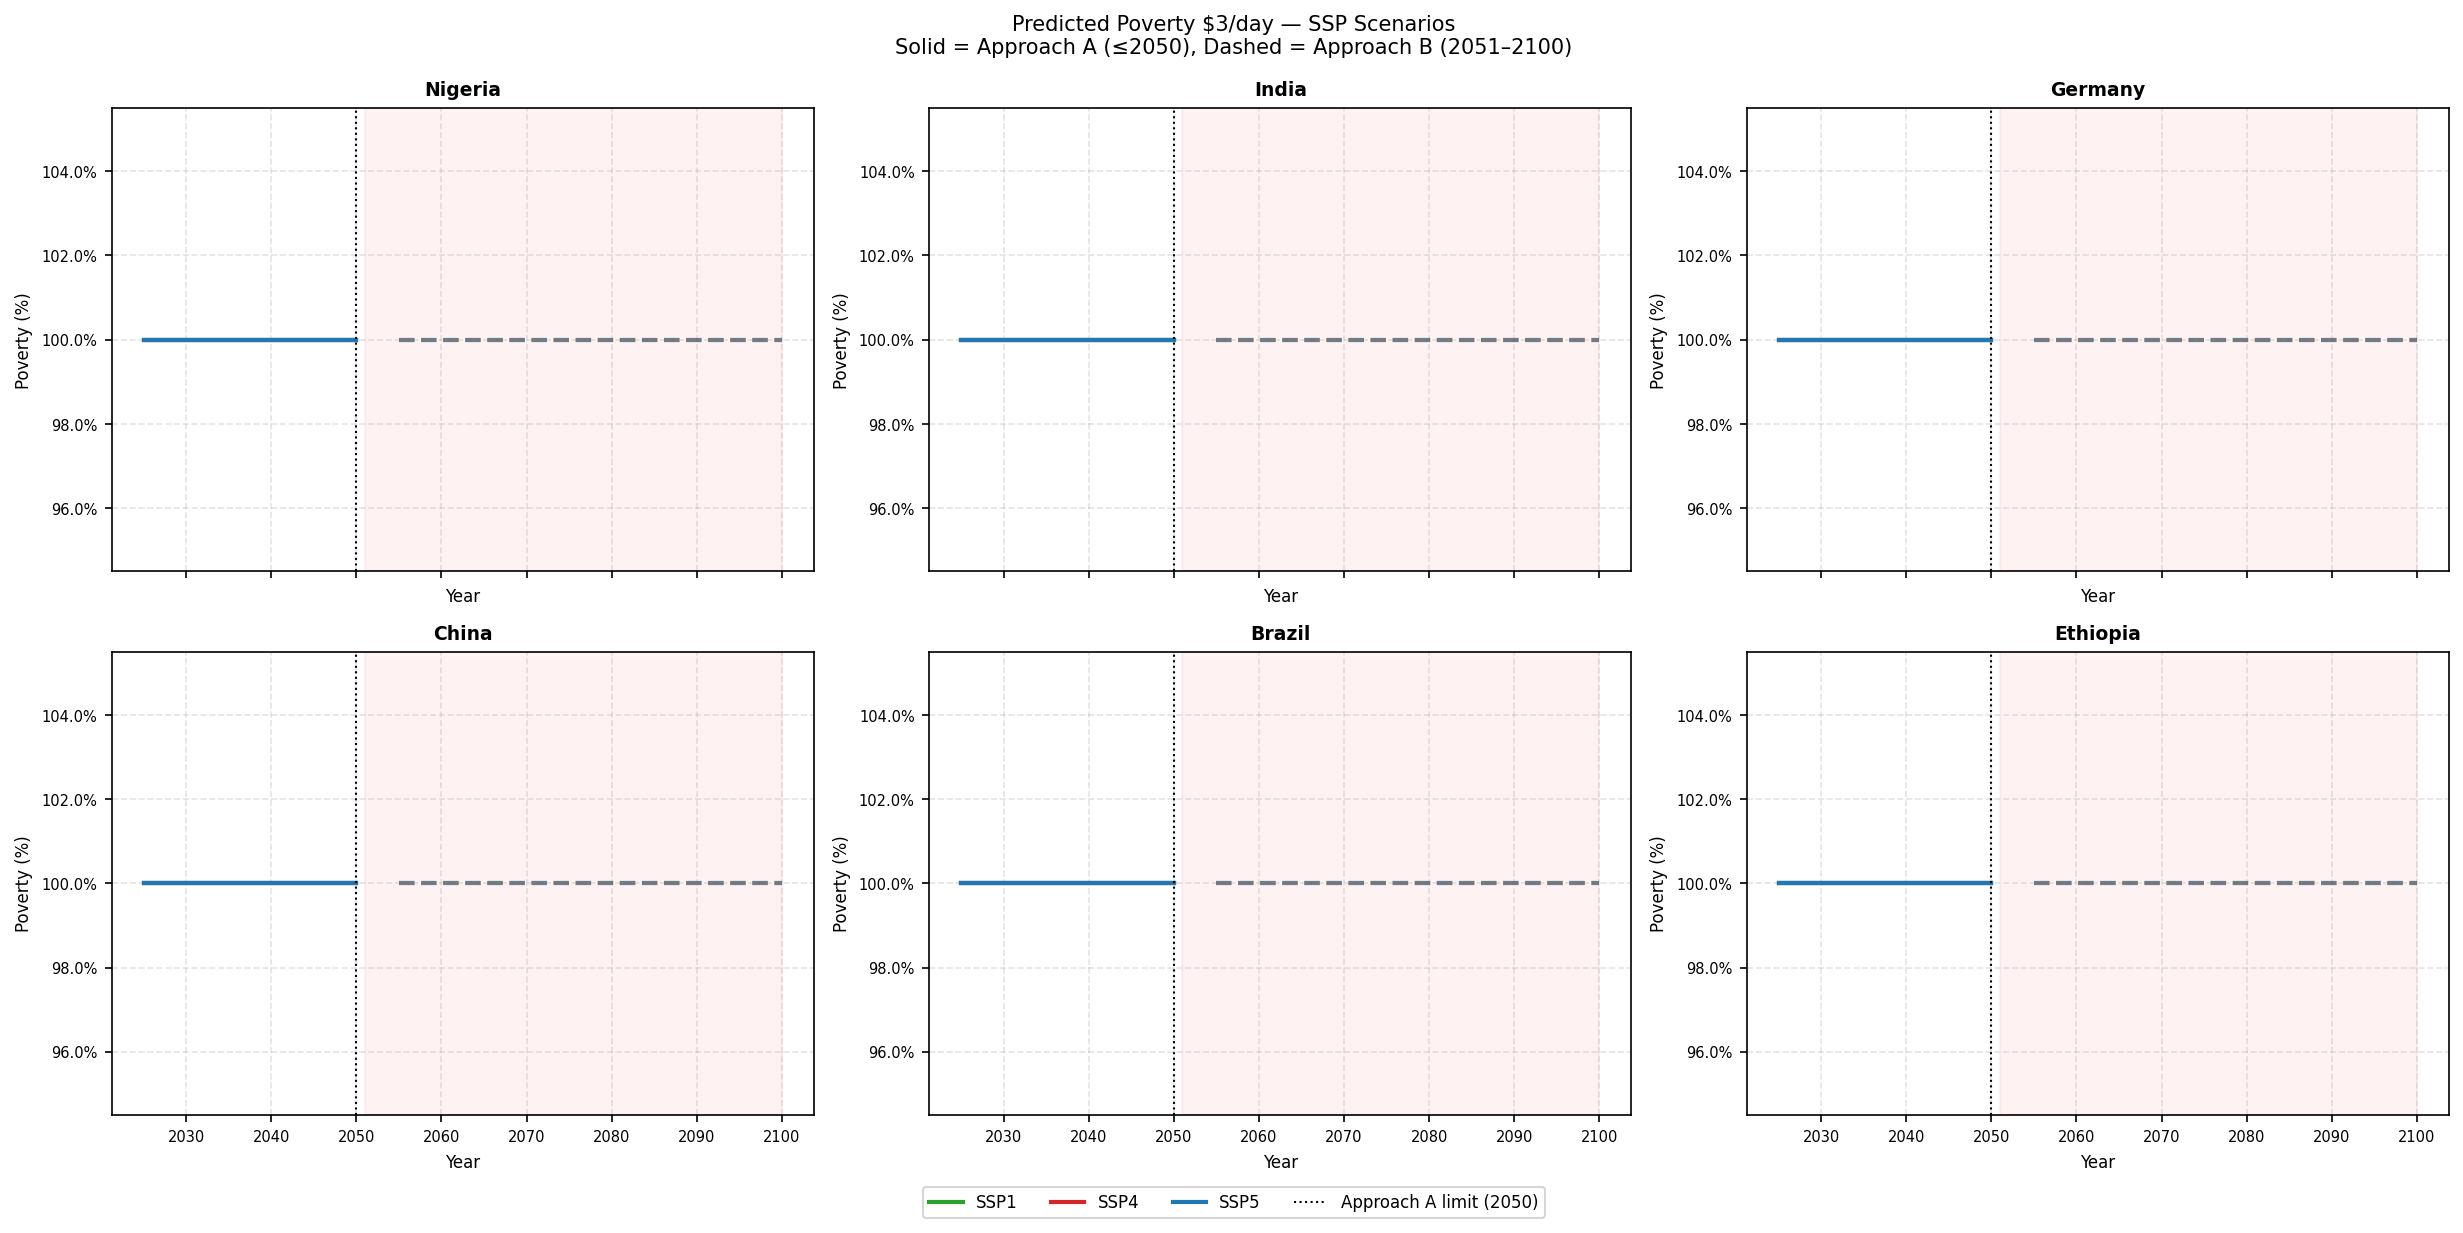


$4.20/day


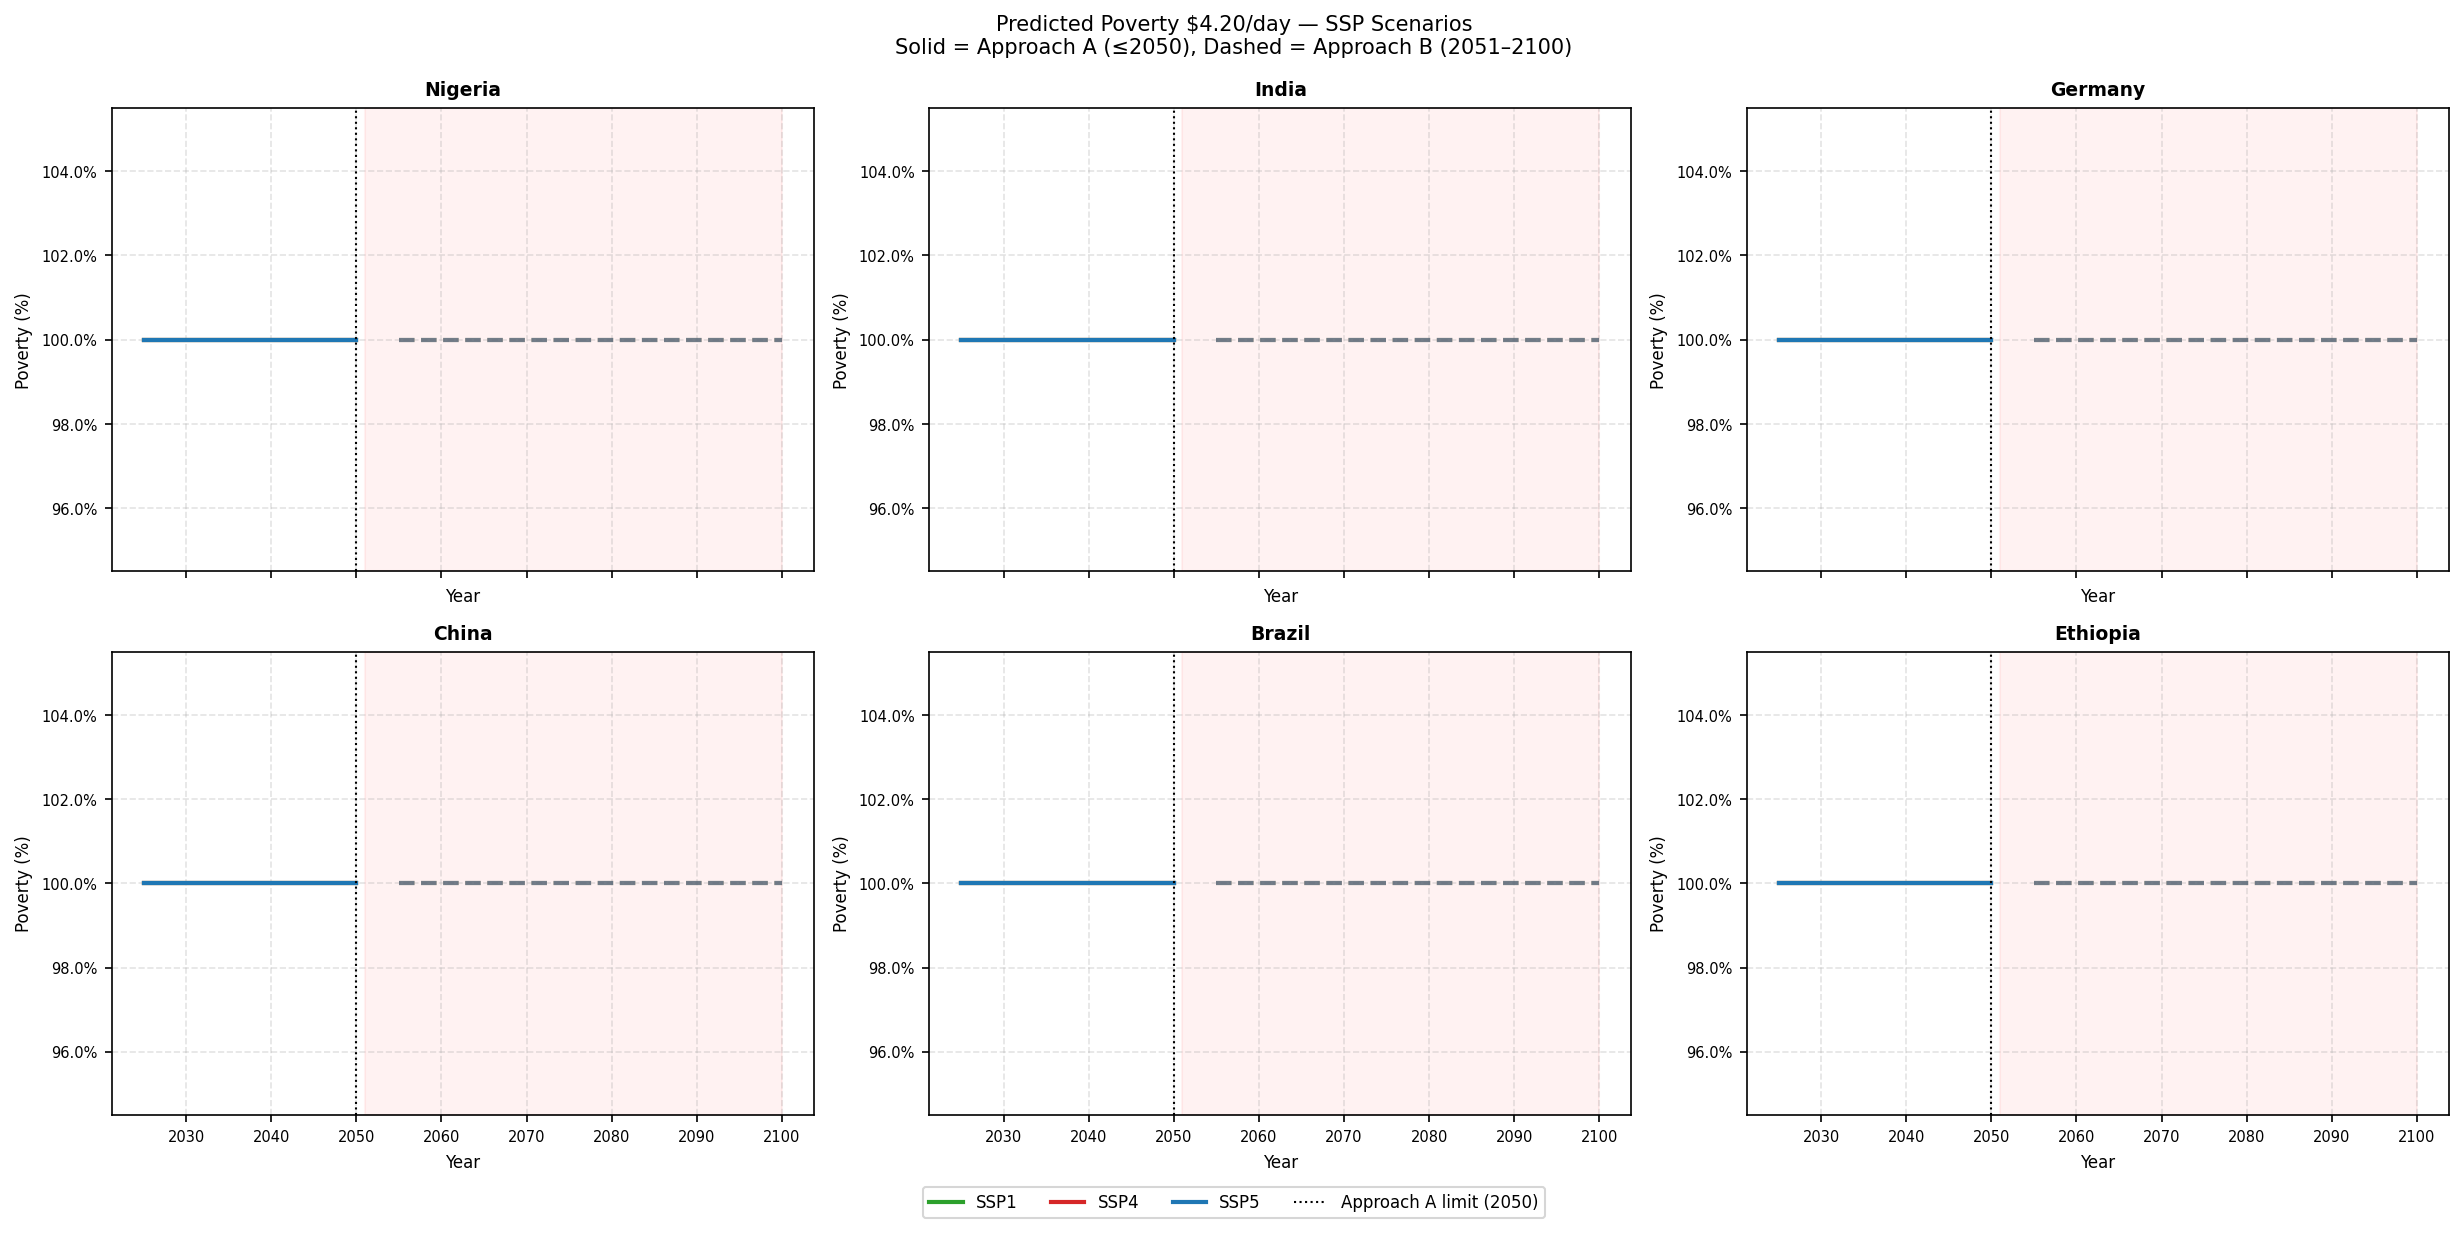


$8.30/day


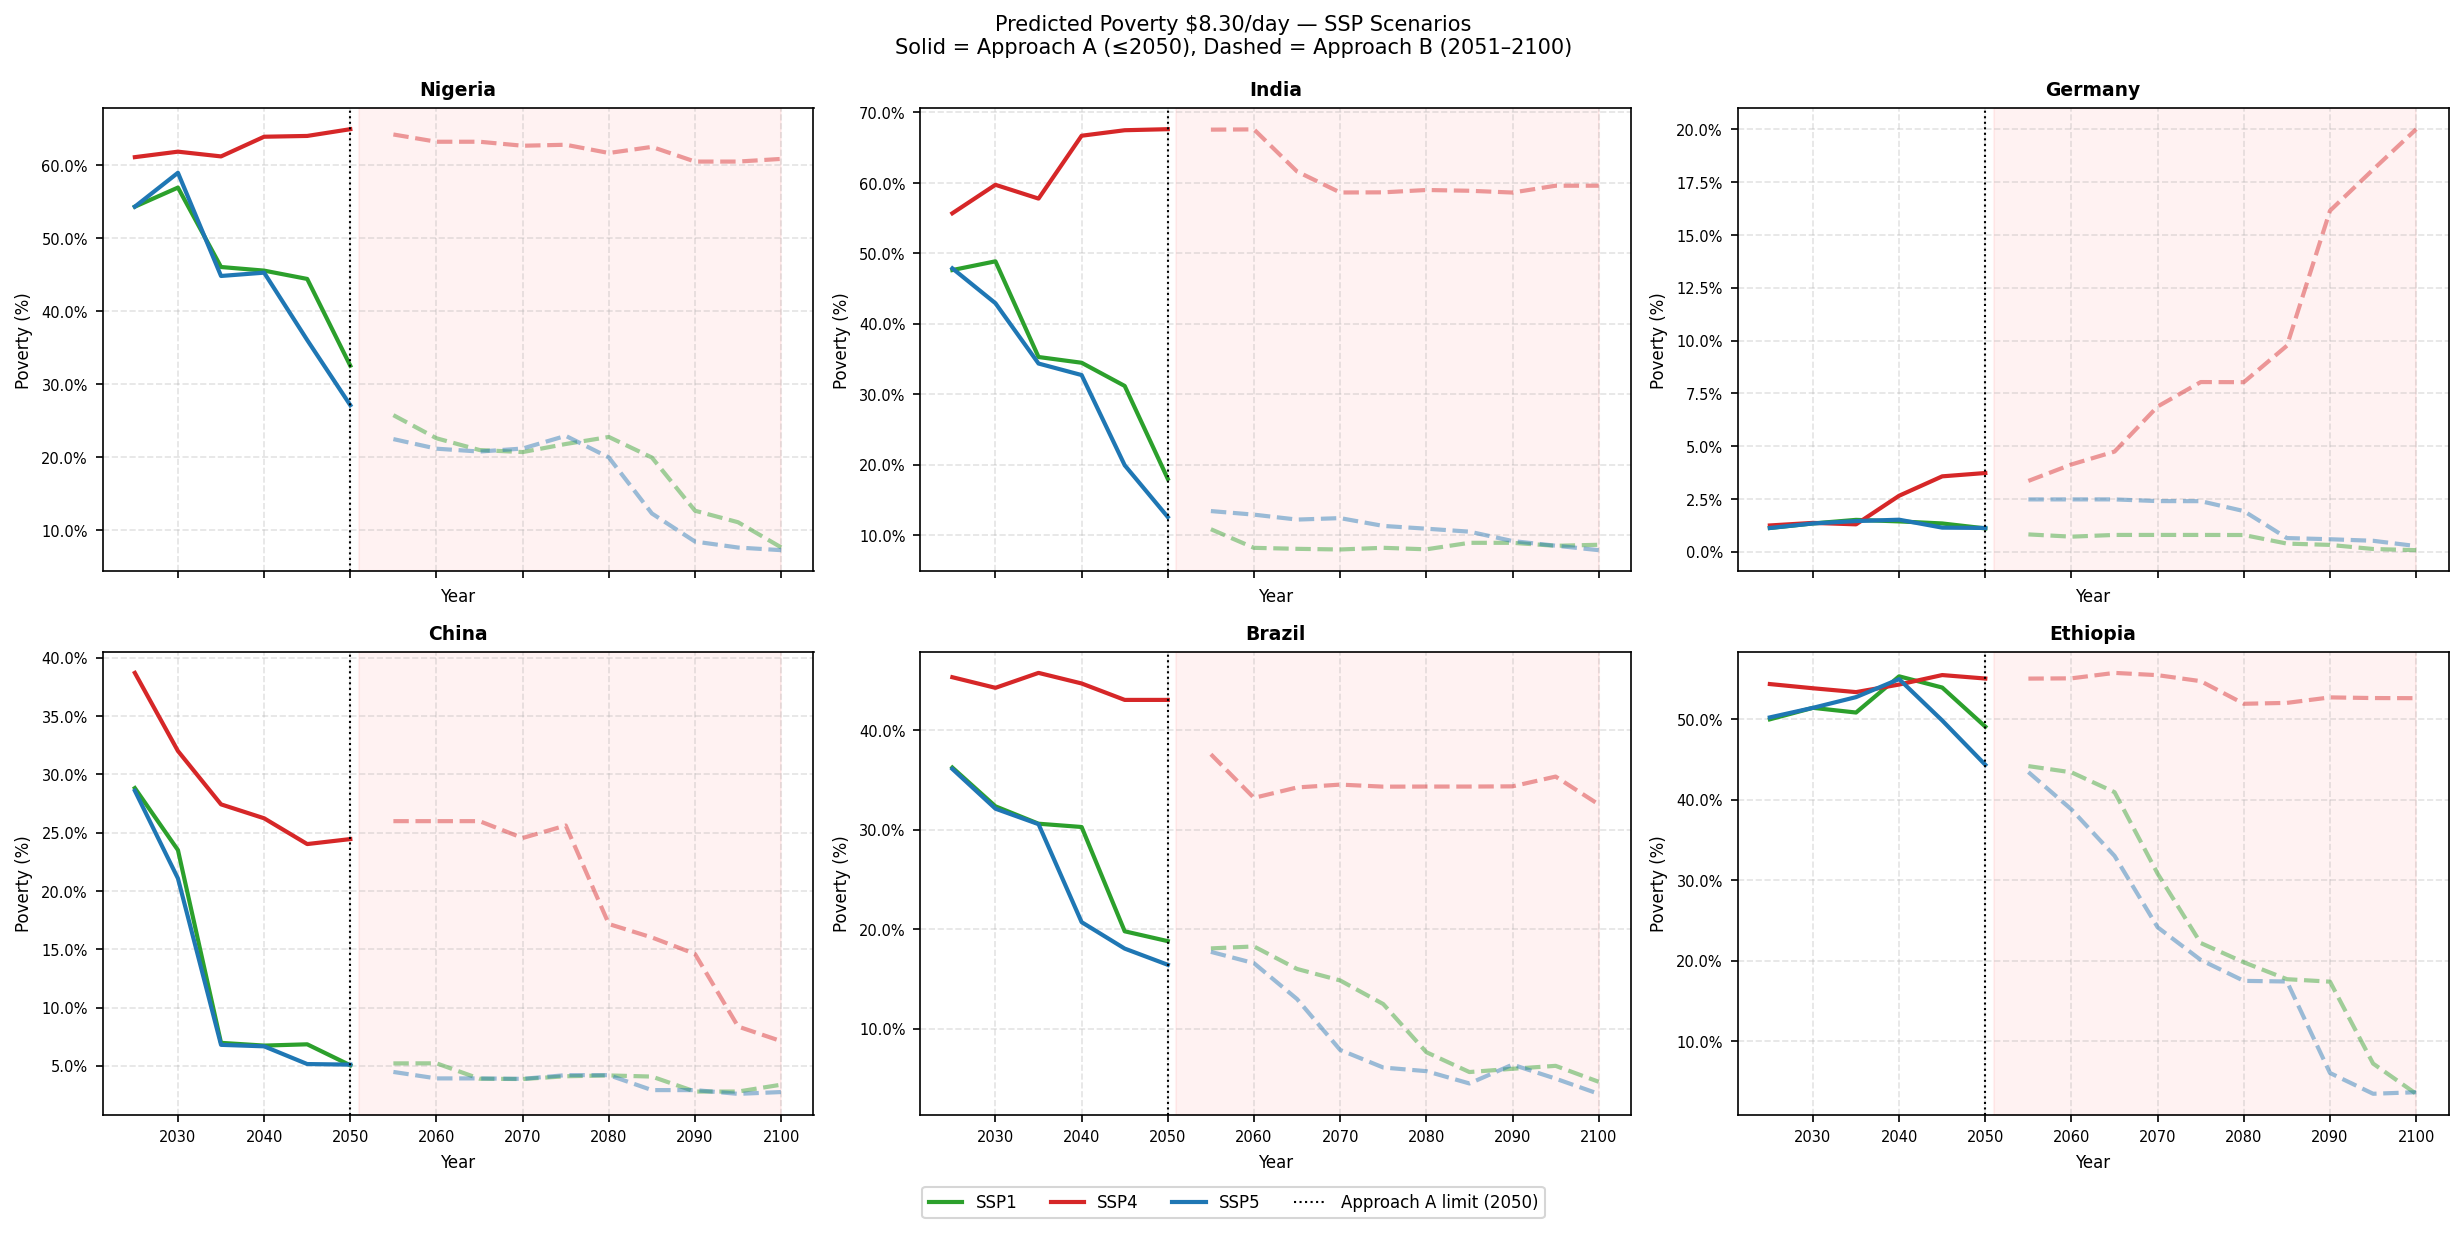


$10/day


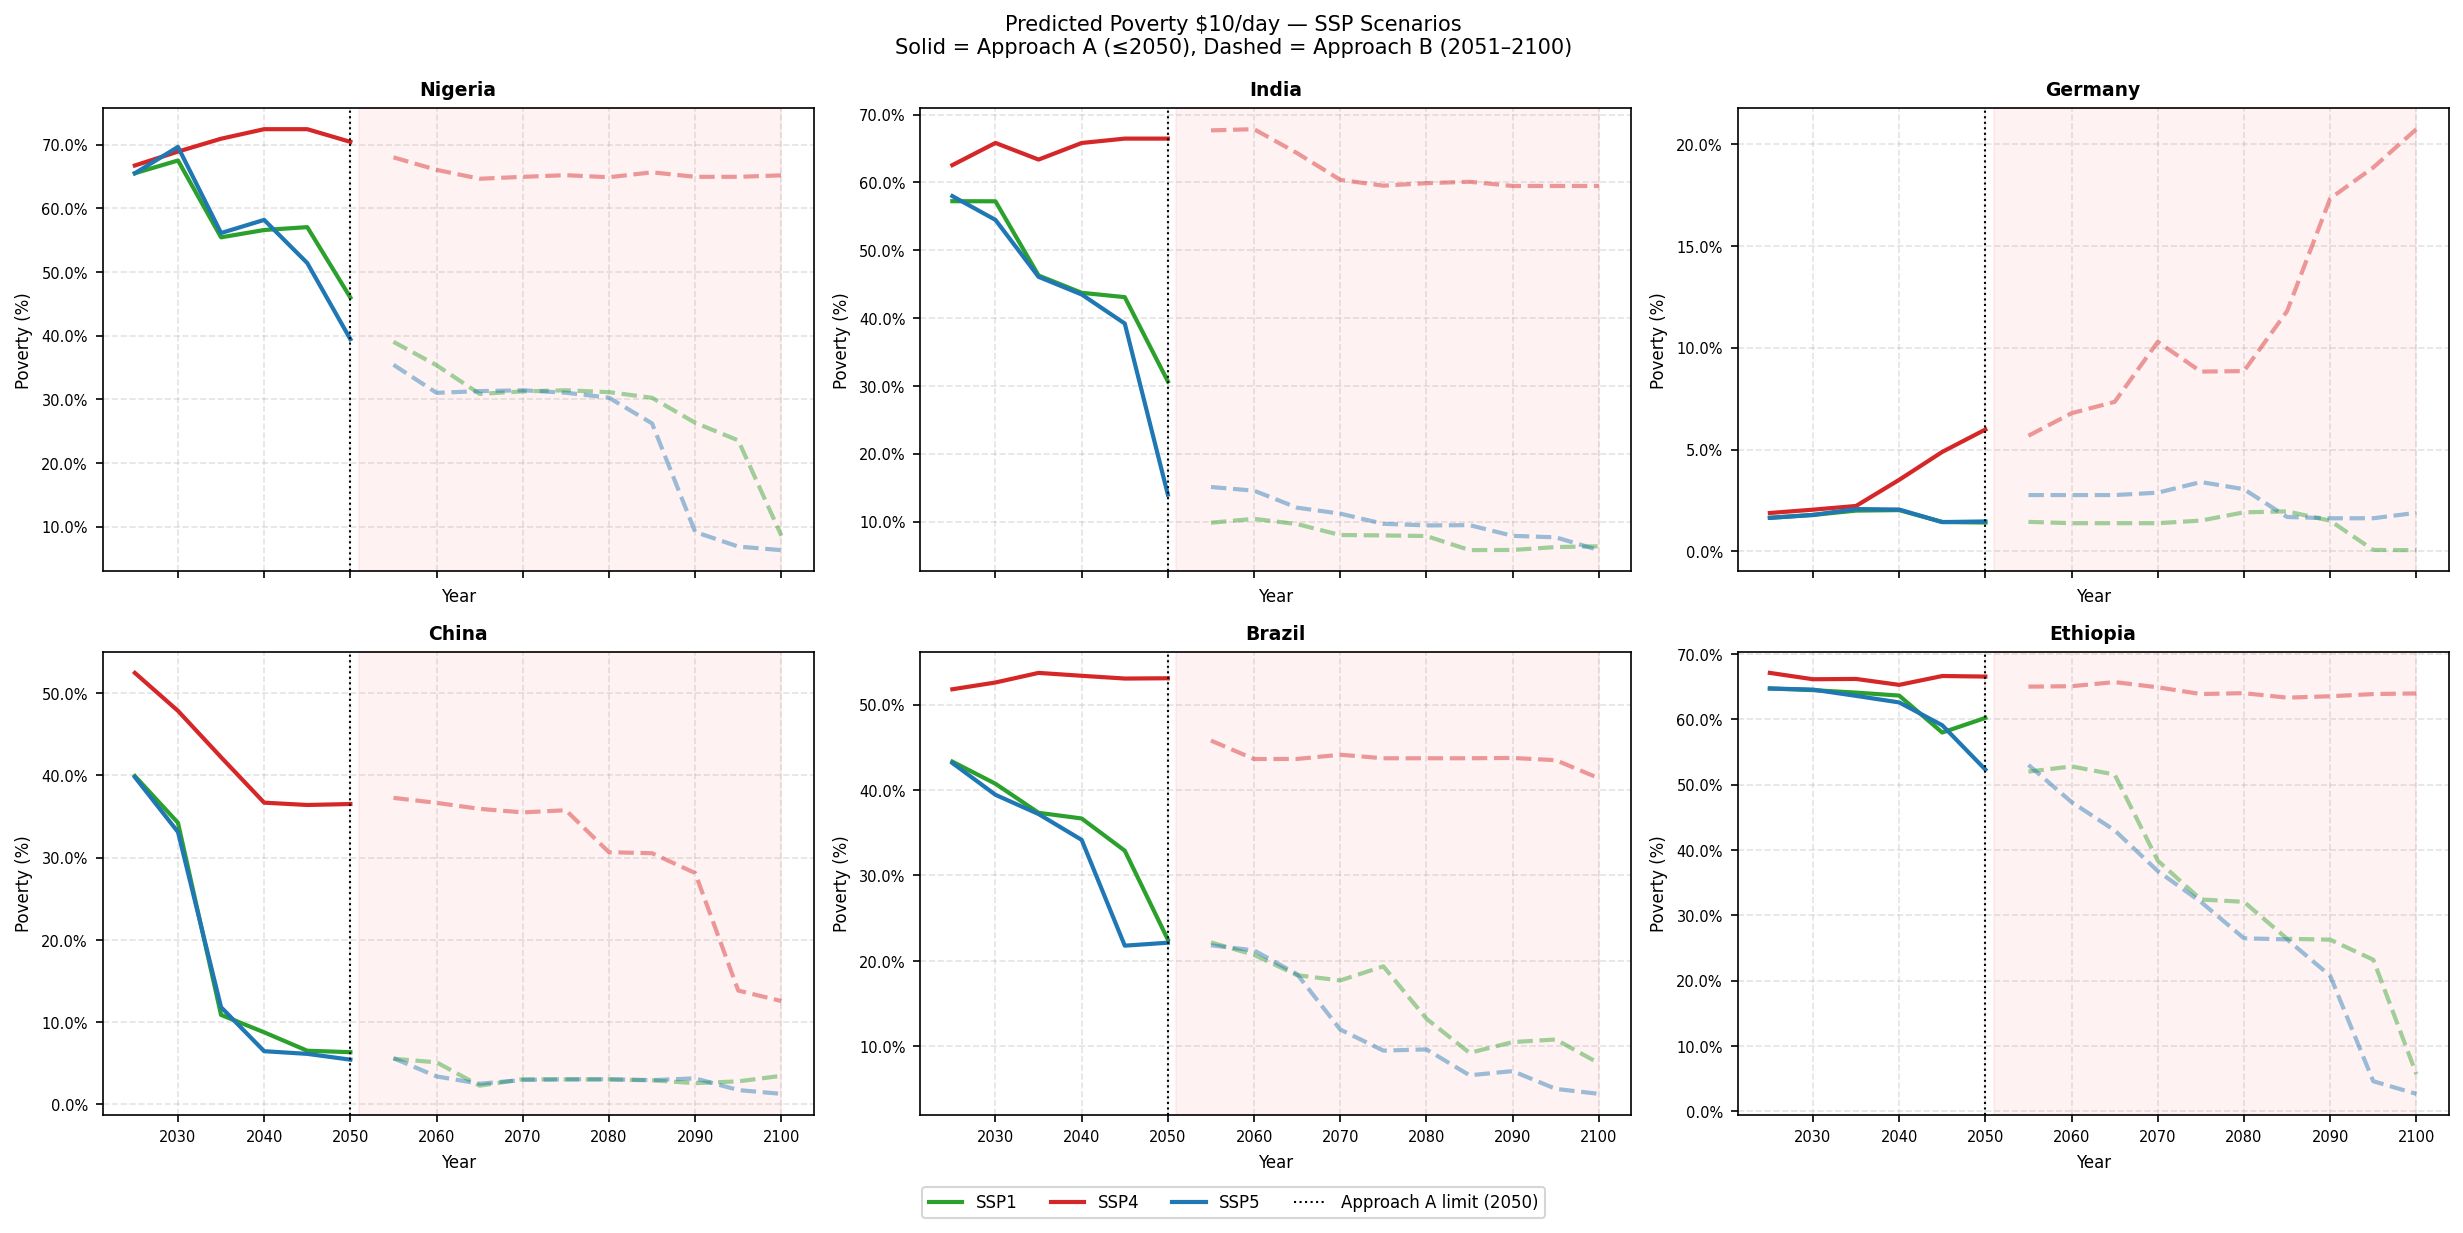

In [7]:
from IPython.display import Image, display
for threshold in ALL_THRESHOLDS:
    slug = threshold.replace("$", "").replace(".", "_")
    p = OUTPUTS_DIR / f"prediction_trajectories_{slug}.png"
    if p.exists():
        print(f"\n{THRESHOLD_DISPLAY[threshold]}")
        display(Image(str(p)))

## 7. Global heatmap

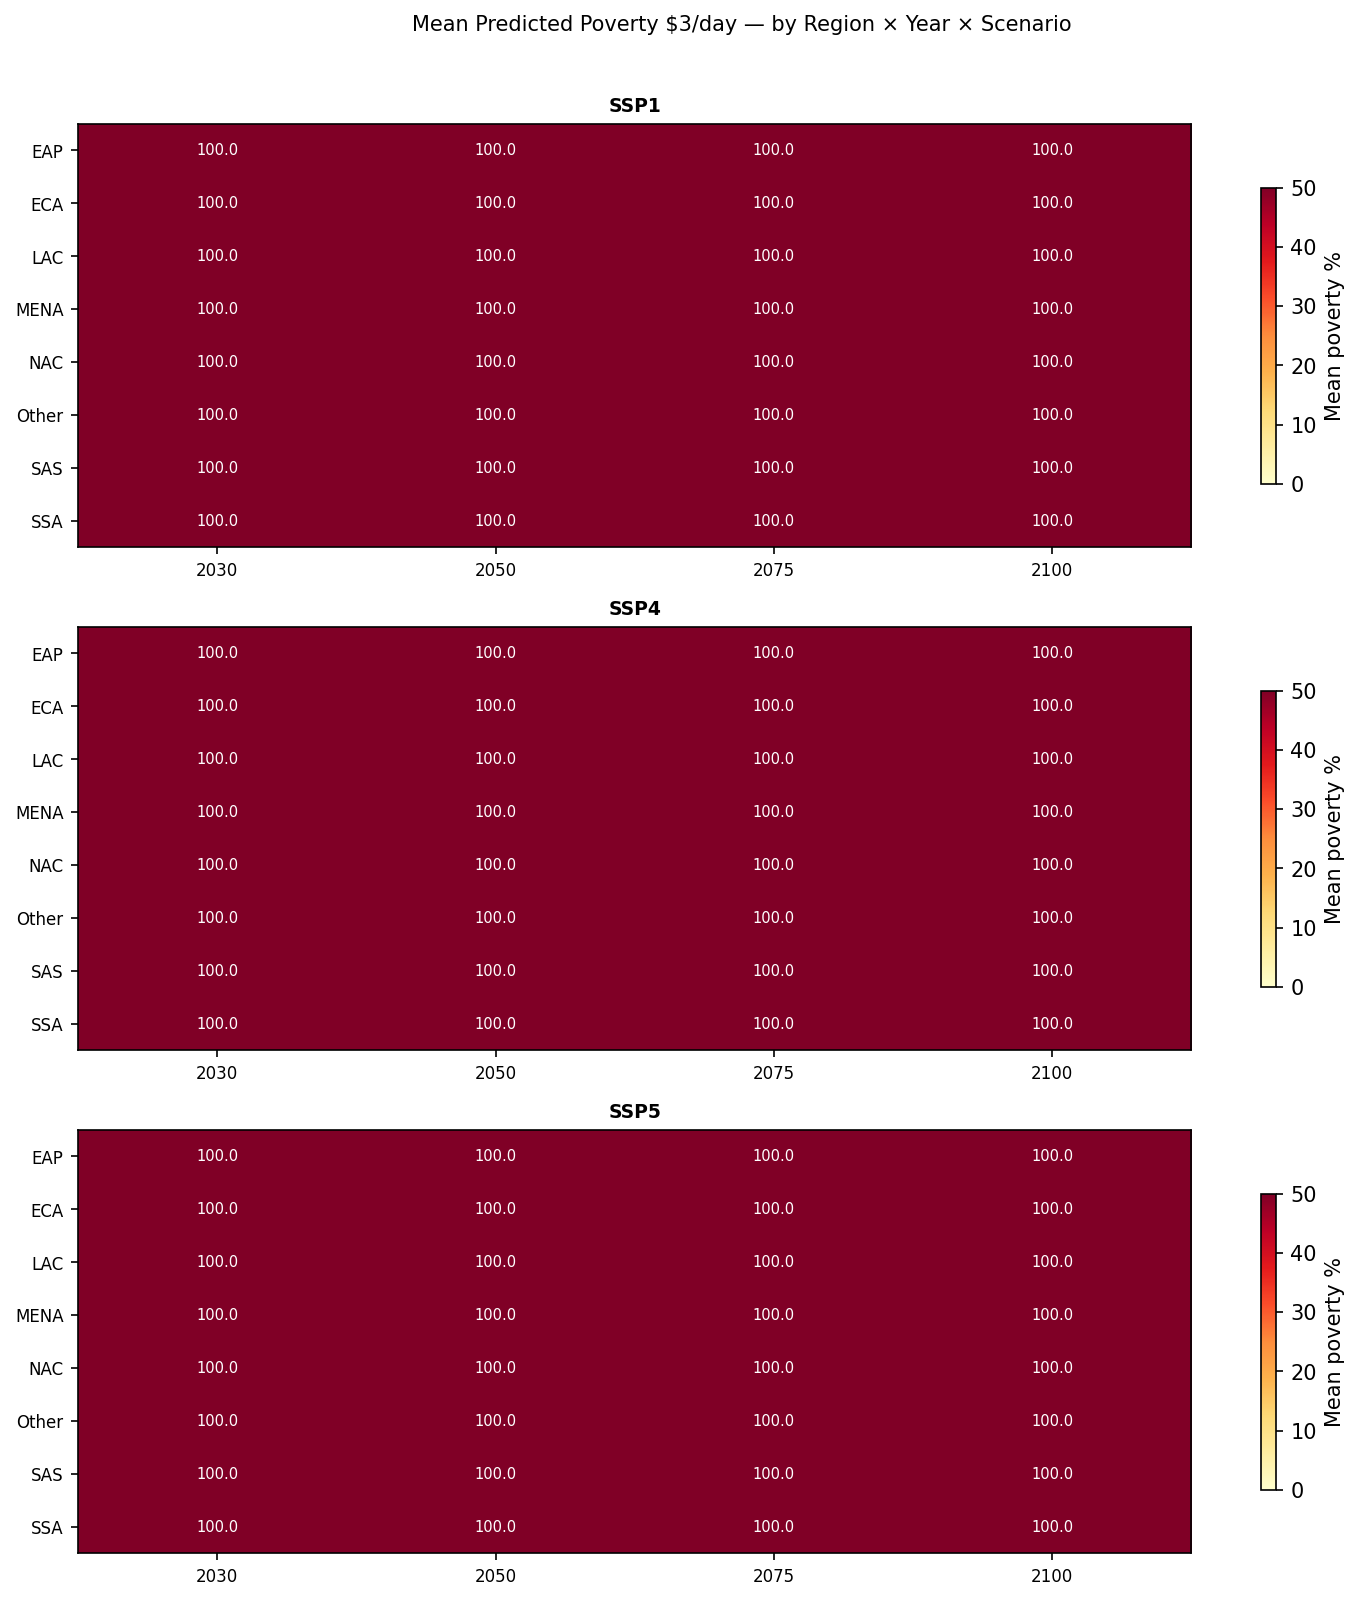

In [8]:
p = OUTPUTS_DIR / "prediction_global_heatmap.png"
if p.exists():
    display(Image(str(p)))

## 8. Top-10 highest poverty countries

In [9]:
top10 = pd.read_csv(OUTPUTS_DIR / "top10_countries_by_scenario.csv")
print("Top-10 by scenario/threshold/year:")
print(top10.head(30).to_string(index=False))

print("\nTop-10 highest poverty countries — $3/day, SSP4, year 2050:")
sub = top10[
    (top10["scenario"] == "SSP4") &
    (top10["poverty_threshold"] == "$3") &
    (top10["year"] == 2050)
]
print(sub[["rank","country_name","predicted_poverty","extrapolation_flag"]].to_string(index=False))

Top-10 by scenario/threshold/year:
scenario poverty_threshold  year  rank    country_name country_code  predicted_poverty  extrapolation_flag
    SSP1                $3  2030     1         Algeria          DZA              100.0               False
    SSP1                $3  2030     2         Morocco          MAR              100.0               False
    SSP1                $3  2030     3         Namibia          NAM              100.0               False
    SSP1                $3  2030     4           Nepal          NPL              100.0               False
    SSP1                $3  2030     5     Netherlands          NLD              100.0               False
    SSP1                $3  2030     6     New Zealand          NZL              100.0               False
    SSP1                $3  2030     7       Nicaragua          NIC              100.0               False
    SSP1                $3  2030     8           Niger          NER              100.0               False
  

## 9. Summary statistics

In [10]:
stats = pd.read_csv(OUTPUTS_DIR / "prediction_summary_stats.csv")

print("Global mean poverty — $3/day threshold:")
sub = stats[stats["poverty_threshold"] == "$3"][
    ["scenario", "year", "approach", "mean", "median", "p10", "p90", "n"]
].query("year in [2030, 2050, 2075, 2100]")
print(sub.to_string(index=False))

Global mean poverty — $3/day threshold:
scenario  year approach  mean  median   p10   p90   n
    SSP1  2030        A 100.0   100.0 100.0 100.0 150
    SSP1  2050        A 100.0   100.0 100.0 100.0 150
    SSP1  2075        B 100.0   100.0 100.0 100.0 150
    SSP1  2100        B 100.0   100.0 100.0 100.0 150
    SSP4  2030        A 100.0   100.0 100.0 100.0 150
    SSP4  2050        A 100.0   100.0 100.0 100.0 150
    SSP4  2075        B 100.0   100.0 100.0 100.0 150
    SSP4  2100        B 100.0   100.0 100.0 100.0 150
    SSP5  2030        A 100.0   100.0 100.0 100.0 150
    SSP5  2050        A 100.0   100.0 100.0 100.0 150
    SSP5  2075        B 100.0   100.0 100.0 100.0 150
    SSP5  2100        B 100.0   100.0 100.0 100.0 150


## 10. Scenario divergence analysis

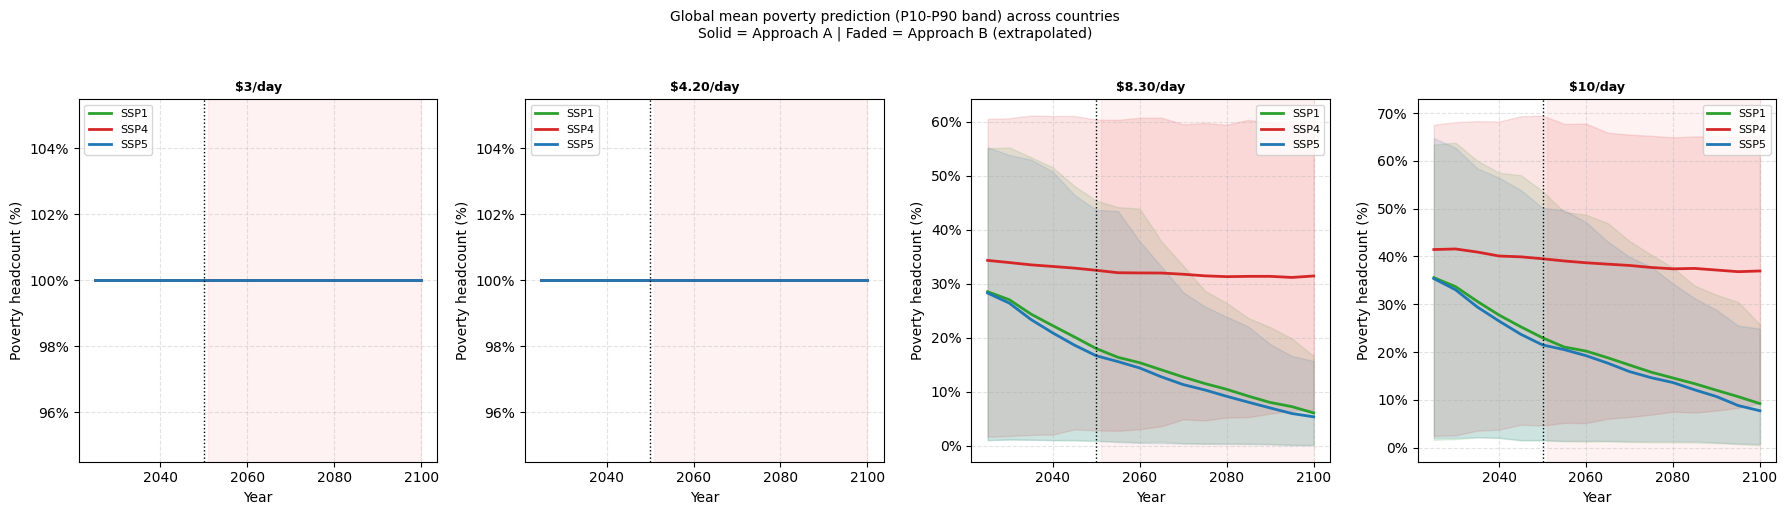

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)

for ax, threshold in zip(axes, ALL_THRESHOLDS):
    sub = stats[stats["poverty_threshold"] == threshold]
    for ssp in SSP_SCENARIOS:
        g = sub[sub["scenario"] == ssp].sort_values("year")
        c = SCENARIO_COLORS.get(ssp, "grey")
        ax.plot(g["year"], g["mean"], color=c, linewidth=2, label=ssp)
        ax.fill_between(g["year"], g["p10"], g["p90"],
                        color=c, alpha=0.12)
    ax.axvline(2050, color="black", linestyle=":", linewidth=1)
    ax.axvspan(2051, 2100, alpha=0.05, color="red")
    ax.set_title(f"{THRESHOLD_DISPLAY[threshold]}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Poverty headcount (%)")
    ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.35)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle(
    "Global mean poverty prediction (P10-P90 band) across countries\n"
    "Solid = Approach A | Faded = Approach B (extrapolated)",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "scenario_divergence_all_thresholds.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 11. Approach A vs B comparison (prediction change after 2050)

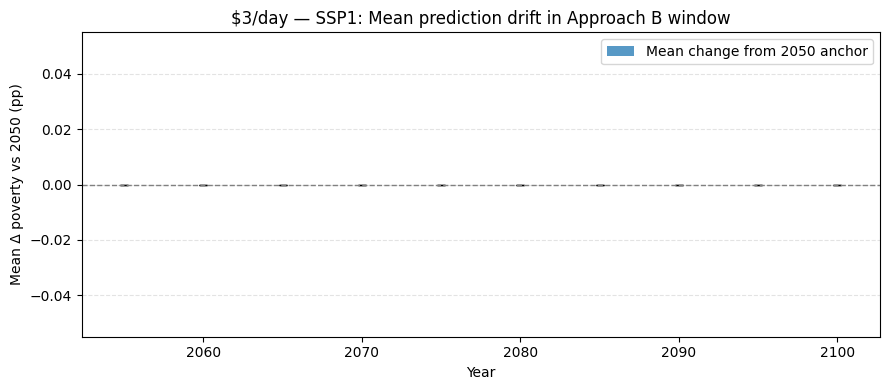

In [12]:
# For $3 / SSP1: show how much predictions change in the Approach B window
sub = preds[
    (preds["poverty_threshold"] == "$3") &
    (preds["scenario"] == "SSP1")
]

# Anchor at 2050
anchor = sub[sub["year"] == 2050][["country_name", "predicted_poverty"]]    .rename(columns={"predicted_poverty": "pred_2050"})
beyond = sub[sub["year"] > 2050].merge(anchor, on="country_name", how="left")
beyond["change_from_2050"] = beyond["predicted_poverty"] - beyond["pred_2050"]

drift_by_year = beyond.groupby("year")["change_from_2050"].agg(["mean","std"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(drift_by_year.index, drift_by_year["mean"],
       color="#1f77b4", alpha=0.75, label="Mean change from 2050 anchor")
ax.errorbar(drift_by_year.index, drift_by_year["mean"],
            yerr=drift_by_year["std"], fmt="none", color="black", capsize=3)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Year"); ax.set_ylabel("Mean Δ poverty vs 2050 (pp)")
ax.set_title("$3/day — SSP1: Mean prediction drift in Approach B window")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.35, axis="y")
plt.tight_layout(); plt.show()

## 12. Country-level sanity checks

In [13]:
# Spot-check 6 countries spanning income levels
check_countries = ["Germany", "United States", "Brazil", "India", "Nigeria", "Ethiopia"]
available = preds["country_name"].unique()
check_countries = [c for c in check_countries if c in available]

print("Spot-check: predicted poverty $3/day, SSP1, selected years")
print(f"{'Country':<25}  {'2025':>7}  {'2030':>7}  {'2050':>7}  {'2075':>7}  {'2100':>7}")
print("-" * 65)
for country in check_countries:
    row_vals = {}
    for yr in [2025, 2030, 2050, 2075, 2100]:
        sub = preds[
            (preds["country_name"] == country) &
            (preds["poverty_threshold"] == "$3") &
            (preds["scenario"] == "SSP1") &
            (preds["year"] == yr)
        ]["predicted_poverty"]
        row_vals[yr] = f"{sub.values[0]:.1f}%" if len(sub) > 0 else " n/a "
    print(f"  {country:<23}  {row_vals[2025]:>7}  {row_vals[2030]:>7}  "
          f"{row_vals[2050]:>7}  {row_vals[2075]:>7}  {row_vals[2100]:>7}")

Spot-check: predicted poverty $3/day, SSP1, selected years
Country                       2025     2030     2050     2075     2100
-----------------------------------------------------------------
  Germany                   100.0%   100.0%   100.0%   100.0%   100.0%
  United States             100.0%   100.0%   100.0%   100.0%   100.0%
  Brazil                    100.0%   100.0%   100.0%   100.0%   100.0%
  India                     100.0%   100.0%   100.0%   100.0%   100.0%
  Nigeria                   100.0%   100.0%   100.0%   100.0%   100.0%
  Ethiopia                  100.0%   100.0%   100.0%   100.0%   100.0%


## 13. Final file listing

In [14]:
main_out = DATA_FINAL_DIR / "poverty_predictions_ssp.csv"
aux_outs = [
    OUTPUTS_DIR / "top10_countries_by_scenario.csv",
    OUTPUTS_DIR / "prediction_summary_stats.csv",
    OUTPUTS_DIR / "prediction_global_heatmap.png",
    OUTPUTS_DIR / "scenario_divergence_all_thresholds.png",
] + [OUTPUTS_DIR / f"prediction_trajectories_{t.replace('$','').replace('.','_')}.png"
     for t in ALL_THRESHOLDS]

print("=== Final prediction outputs ===")
for p in [main_out] + aux_outs:
    if p.exists():
        print(f"  ✓  {p.name:<50}  {p.stat().st_size:>9,} bytes")
    else:
        print(f"  ✗  {p.name} — MISSING")

=== Final prediction outputs ===
  ✓  poverty_predictions_ssp.csv                         1,367,854 bytes
  ✓  top10_countries_by_scenario.csv                        20,823 bytes
  ✓  prediction_summary_stats.csv                           10,376 bytes
  ✓  prediction_global_heatmap.png                         109,496 bytes
  ✓  scenario_divergence_all_thresholds.png                202,335 bytes
  ✓  prediction_trajectories_3.png                         120,787 bytes
  ✓  prediction_trajectories_4_20.png                      121,339 bytes
  ✓  prediction_trajectories_8_30.png                      294,062 bytes
  ✓  prediction_trajectories_10.png                        286,734 bytes


## 14. Summary

### `poverty_predictions_ssp.csv` — dashboard schema

The dashboard will read this file and filter on:
- `poverty_threshold` → dropdown selector (`$3` / `$4.20` / `$8.30` / `$10`)
- `scenario` → SSP1 / SSP4 / SSP5
- `year` → slider or dropdown
- `approach` → optional toggle to hide Approach B extrapolations
- `extrapolation_flag` → optional opacity overlay to signal uncertainty

Suggested aggregations for the dashboard:
- **Choropleth map**: `predicted_poverty` by `country_code` at a selected year
- **Line chart**: one line per scenario for a selected country
- **Bar chart**: top-N countries at a selected year
- **Uncertainty toggle**: hide `approach == "B"` for a conservative view

**Next**: `07_dashboard.ipynb` — Plotly Dash / Streamlit interactive visualisation.
